Loading bayesm draws …
Loading Liesel draws …
  bayesm : R=10000, K=2, nvar=4
  Liesel : R=10000, K=2, nvar=4

Grid extents (Padded with 99th percentile std for tails):
  ASC 1       [-6.407,  +10.086]
  ASC 2       [-5.088,  +9.202]
  ASC 3       [-7.433,  +7.804]
  Price       [-6.847,  +4.088]

Computing component-level densities …


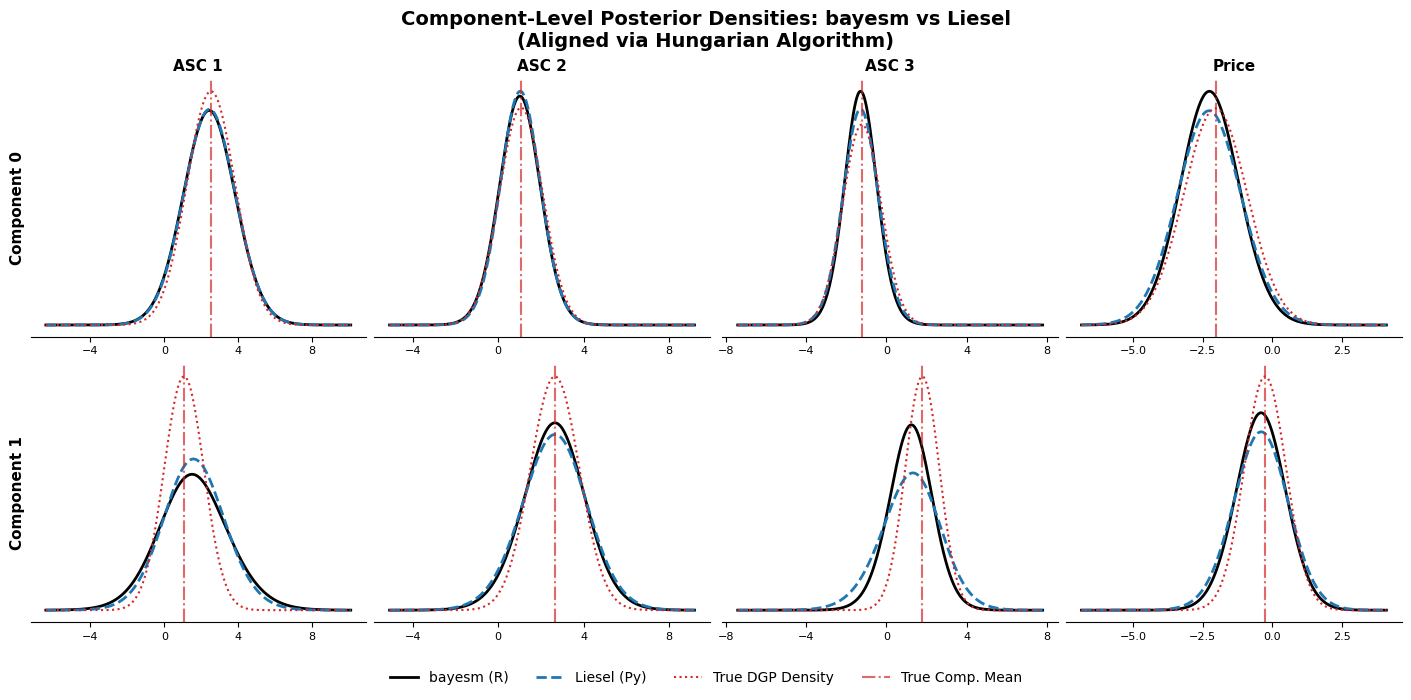


Computing marginal densities …


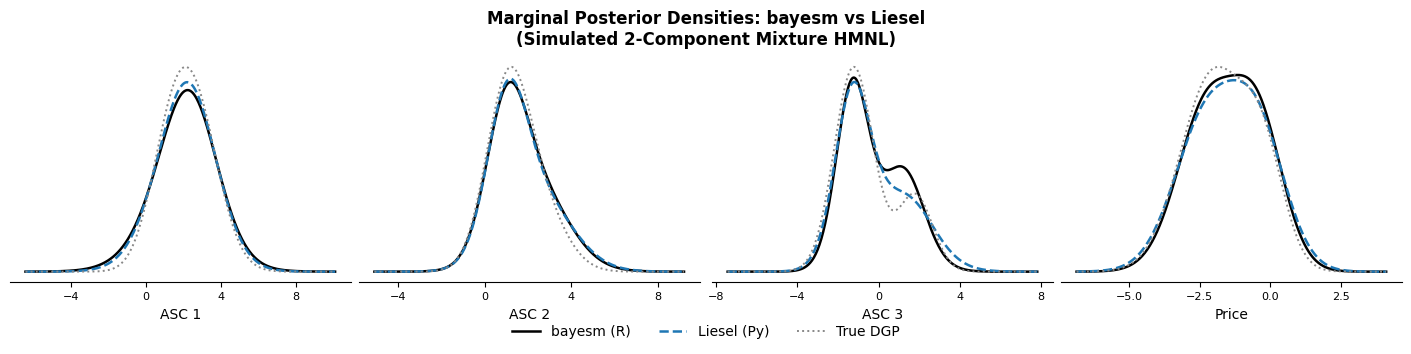


Computing moments for all MCMC draws...

=== Posterior Expected Overall Mixture Means (E[θ]) ===


,True DGP,bayesm,Liesel
ASC 1,2.162,2.105,2.122
ASC 2,1.470,1.673,1.690
ASC 3,-0.471,-0.259,-0.253
Price,-1.595,-1.475,-1.484



=== Posterior Expected Overall Variance (Diag(Var(θ))) ===


,True DGP,bayesm,Liesel
ASC 1,1.958,2.914,2.550
ASC 2,1.578,2.077,2.139
ASC 3,2.581,2.371,2.892
Price,1.709,1.786,2.000



=== Posterior Expected Component Probabilities (pvec) ===


,True DGP,bayesm,Liesel
Component 0,0.75,0.5822,0.5794
Component 1,0.25,0.4178,0.4206


In [1]:
# ==============================================================================
# compare_marginals.py  (Notebook Version - No main guard)
# ==============================================================================

import json
import pathlib
import pickle

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
from scipy.optimize import linear_sum_assignment

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR     = pathlib.Path("Data")
RDATA_PATH   = DATA_DIR / "bayesm_output_simulated_2comp.RData"
PICKLE_PATH  = DATA_DIR / "simulated_2comp_liesel.pkl"
JSON_PATH    = "simulated_hmnl_data.json"
N_GRID       = 500
PARAM_LABELS = ["ASC 1", "ASC 2", "ASC 3", "Price"]

# ── 1. Loaders ────────────────────────────────────────────────────────────────
def load_bayesm_full(rdata_path, K, nvar):
    rdata   = pyreadr.read_r(str(rdata_path))
    mu_raw  = rdata["mu_draws_df"].values.astype(float)
    cov_raw = rdata["cov_draws_df"].values.astype(float)
    pvec    = rdata["pvec_draws_df"].values.astype(float)
    R       = mu_raw.shape[0]

    mu  = mu_raw.reshape(R, K, nvar)
    cov = cov_raw.reshape(R, K, nvar, nvar) # Reshape to full matrices
    
    truth = {k: np.array(rdata[k]) for k in ("TRUE_MU_K", "TRUE_PVEC", "TRUE_SIGMA_K") if k in rdata}
    if "TRUE_PVEC" in truth:
        truth["TRUE_PVEC"] = truth["TRUE_PVEC"].ravel()
        
    return mu, cov, pvec, truth

def load_liesel_full(pickle_path):
    with open(pickle_path, "rb") as f:
        d = pickle.load(f)
    return d["mu"], d["sigma"], d["pvec"]

# ── 2. Grid construction ──────────────────────────────────────────────────────
def build_grids(mu_b, std_b, mu_l, std_l, truth, labels, n_grid=500):
    """
    Constructs the evaluation grid for the density functions.
    
    Ref: Rossi (2006), Section 5.5:
    "We set down a grid of possible values for each element of beta and then 
    evaluate the posterior mean of the density in (5.5.19)."
    """
    nvar  = mu_b.shape[2]
    K     = mu_b.shape[1]
    grids = []

    print("\nGrid extents (Padded with 99th percentile std for tails):")
    for j in range(nvar):
        label = labels[j] if j < len(labels) else f"Param_{j}"

        sides = []
        for mu_arr, std_arr in [(mu_b, std_b), (mu_l, std_l)]:
            mu_lo   = np.percentile(mu_arr[:, :, j], 1)
            mu_hi   = np.percentile(mu_arr[:, :, j], 99)
            # Use the 99th percentile of the standard deviation to pad the tails
            std_pad = np.percentile(std_arr[:, :, j], 99)
            sides  += [mu_lo - 3 * std_pad, mu_hi + 3 * std_pad]

        lo = min(sides[0], sides[2])
        hi = max(sides[1], sides[3])

        # Also cover true DGP means plus their standard deviations to ensure they fit
        if "TRUE_MU_K" in truth and "TRUE_SIGMA_K" in truth:
            for k in range(K):
                true_std = np.sqrt(truth["TRUE_SIGMA_K"][k, j, j])
                lo = min(lo, truth["TRUE_MU_K"][k, j] - 3 * true_std)
                hi = max(hi, truth["TRUE_MU_K"][k, j] + 3 * true_std)

        print(f"  {label:<10s}  [{lo:+.3f},  {hi:+.3f}]")
        grids.append(np.linspace(lo, hi, n_grid))

    return grids

# ── 3. Density evaluators ─────────────────────────────────────────────────────
def compute_marginal_densities(mu, std, pvec, grids):
    """
    Implements Rossi (2006) Equation (5.5.19).
    
    "To find the posterior mean of a marginal density for a specific element of beta, 
    we average the marginal densities:"
    d_bar_j(beta_j) = (1/R) * sum_{r=1}^R sum_{k=1}^K pvec_k^r * phi_j(beta_j | mu_k^r, Sigma_k^r)
    
    Where:
    - R is the number of MCMC draws.
    - K is the number of mixture components.
    - phi_j is the normal PDF evaluated for parameter j.
    """
    R, K, nvar = mu.shape
    densities  = []
    for j in range(nvar):
        x = grids[j]
        d = np.zeros(len(x))
        for k in range(K):
            std_k = std[:, k, j].copy()
            std_k = np.clip(std_k, np.percentile(std_k, 1), np.percentile(std_k, 99))
            
            # phi_j(beta_j | mu_k^r, Sigma_k^r)
            pdf_k = norm.pdf(x[:, None], loc=mu[:, k, j], scale=std_k)
            
            # Weight by pvec_k^r and average over all R draws
            d    += np.mean(pvec[:, k] * pdf_k, axis=1)
        densities.append(d)
    return densities

def compute_true_densities(true_mu_k, true_sigma_k, true_pvec, grids):
    """
    Computes the True Data Generating Process (DGP) marginal densities
    following the same logic as Eq 5.5.19 but without the MCMC averaging (R=1).
    """
    K, nvar   = true_mu_k.shape
    densities = []
    for j in range(nvar):
        x = grids[j]
        d = np.zeros(len(x))
        for k in range(K):
            sigma_kj = np.sqrt(true_sigma_k[k, j, j])
            d += true_pvec[k] * norm.pdf(x, loc=true_mu_k[k, j], scale=sigma_kj)
        densities.append(d)
    return densities

def compute_component_densities(mu, std, grids):
    """
    Computes the unweighted component-level densities (phi_j). 
    This isolates the inner component of Eq 5.5.19 before weighting by pvec.
    """
    R, K, nvar = mu.shape
    comp_densities = []
    
    for k in range(K):
        dens_k = []
        for j in range(nvar):
            x = grids[j]
            std_k = std[:, k, j].copy()
            std_k = np.clip(std_k, np.percentile(std_k, 1), np.percentile(std_k, 99))
            
            pdf_k = norm.pdf(x[:, None], loc=mu[:, k, j], scale=std_k)
            dens_k.append(np.mean(pdf_k, axis=1))
        comp_densities.append(dens_k)
        
    return comp_densities

def compute_true_component_densities(true_mu_k, true_sigma_k, grids):
    K, nvar = true_mu_k.shape
    comp_densities = []
    
    for k in range(K):
        dens_k = []
        for j in range(nvar):
            x = grids[j]
            sigma_kj = np.sqrt(true_sigma_k[k, j, j])
            dens_k.append(norm.pdf(x, loc=true_mu_k[k, j], scale=sigma_kj))
        comp_densities.append(dens_k)
        
    return comp_densities

# ── 4. Mixture Moments Evaluator ──────────────────────────────────────────────
def compute_mixture_moments(mu, cov, pvec):
    """
    Implements Rossi et al.(2006) Equation (5.5.2) for the moments of theta (beta).
    
    Assuming observable characteristics z are centered:
    "For this reason, we advise that z be centered so that the mean of theta given 
    average z values will be entirely determined by the normal mixture component means. 
    The moments of theta are as follows:"
    
    Mean: E[theta_i | z_i=z_bar, p, {mu_k}] = mu_bar = sum_{k=1}^K pvec_k * mu_k
    Var:  var(theta_i | ...) = sum_{k=1}^K pvec_k * Sigma_k + sum_{k=1}^K pvec_k * (mu_k - mu_bar)(mu_k - mu_bar)'
    """
    # 1. Overall Mean (E[theta_i]): sum_{k=1}^K pvec_k * mu_k
    mean_theta = np.sum(pvec[:, :, None] * mu, axis=1) 
    
    # 2. Within-Component Variance: sum_{k=1}^K pvec_k * Sigma_k
    var_within = np.sum(pvec[:, :, None, None] * cov, axis=1) 
    
    # 3. Between-Component Variance: sum_{k=1}^K pvec_k * (mu_k - mu_bar)(mu_k - mu_bar)'
    diff = mu - mean_theta[:, None, :] 
    diff_outer = diff[:, :, :, None] * diff[:, :, None, :] 
    var_between = np.sum(pvec[:, :, None, None] * diff_outer, axis=1) 
    
    # Total Variance
    var_theta = var_within + var_between 
    return mean_theta, var_theta

# ==============================================================================
# MAIN EXECUTION (Unindented for Jupyter Notebook)
# ==============================================================================

# ── A. Load Raw Data ──────────────────────────────────────────────────────
print("Loading bayesm draws …")
mu_b, cov_b, pvec_b, truth_b = load_bayesm_full(RDATA_PATH, K=2, nvar=len(PARAM_LABELS))
std_b = np.sqrt(np.maximum(np.diagonal(cov_b, axis1=2, axis2=3), 0.0))

print("Loading Liesel draws …")
mu_l, cov_l, pvec_l = load_liesel_full(PICKLE_PATH)
std_l = np.sqrt(np.maximum(np.diagonal(cov_l, axis1=2, axis2=3), 0.0))

assert mu_b.shape[1:] == mu_l.shape[1:], \
    f"Shape mismatch: bayesm {mu_b.shape} vs Liesel {mu_l.shape}"

K, nvar = mu_b.shape[1], mu_b.shape[2]
print(f"  bayesm : R={mu_b.shape[0]}, K={K}, nvar={nvar}")
print(f"  Liesel : R={mu_l.shape[0]}, K={K}, nvar={nvar}")

# Load True DGP directly from JSON (Bypasses missing RData keys)
with open(JSON_PATH, "r") as f:
    sim_data_raw = json.load(f)
    
true_mu_k    = np.array(sim_data_raw["TRUE_MU_K"])
true_sigma_k = np.array(sim_data_raw["TRUE_SIGMA_K"])
true_pvec    = np.array(sim_data_raw["TRUE_PVEC"])

# Create unified truth dict for diagnostic outputs
truth_full = {
    "TRUE_MU_K": true_mu_k,
    "TRUE_SIGMA_K": true_sigma_k,
    "TRUE_PVEC": true_pvec
}

# ── B. Grids ──────────────────────────────────────────────────────────────
grids = build_grids(mu_b, std_b, mu_l, std_l, truth_full, PARAM_LABELS, n_grid=N_GRID)

# ── C. Component-Level Densities & Label Alignment (Figure 1) ─────────────
print("\nComputing component-level densities …")
comp_dens_bayesm = compute_component_densities(mu_b, std_b, grids)
comp_dens_liesel = compute_component_densities(mu_l, std_l, grids)
comp_dens_true   = compute_true_component_densities(true_mu_k, true_sigma_k, grids)

# Align Components using Hungarian Algorithm to handle Label Switching
mu_b_mean = mu_b.mean(axis=0)
mu_l_mean = mu_l.mean(axis=0)

cost_matrix_l = np.sum((mu_l_mean[:, None, :] - mu_b_mean[None, :, :]) ** 2, axis=-1)
row_ind_l, col_ind_l = linear_sum_assignment(cost_matrix_l)
mapped_liesel_idx = {b_idx: l_idx for l_idx, b_idx in zip(row_ind_l, col_ind_l)}

cost_matrix_t = np.sum((true_mu_k[:, None, :] - mu_b_mean[None, :, :]) ** 2, axis=-1)
row_ind_t, col_ind_t = linear_sum_assignment(cost_matrix_t)
mapped_true_idx = {b_idx: t_idx for t_idx, b_idx in zip(row_ind_t, col_ind_t)}

# Plot Component-Level Figure
fig_comp, axes_comp = plt.subplots(K, nvar, figsize=(nvar * 3.5, K * 3.2), constrained_layout=True)

for k in range(K):
    l_idx = mapped_liesel_idx[k]
    t_idx = mapped_true_idx[k]
    
    for j in range(nvar):
        ax = axes_comp[k, j] if K > 1 else axes_comp[j]
        
        ax.plot(grids[j], comp_dens_bayesm[k][j],   color="black",   lw=2.0,          label="bayesm (R)")
        ax.plot(grids[j], comp_dens_liesel[l_idx][j], color="#1f77b4", lw=2.0, ls="--", label="Liesel (Py)")
        ax.plot(grids[j], comp_dens_true[t_idx][j],   color="#D62728", lw=1.5, ls=":",  label="True DGP Density")
        
        true_mean_val = true_mu_k[t_idx, j]
        ax.axvline(true_mean_val, color="#D62728", lw=1.5, ls="-.", alpha=0.7, label="True Comp. Mean")
            
        if k == 0:
            ax.set_title(PARAM_LABELS[j] if j < len(PARAM_LABELS) else f"Param {j}", fontsize=11, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"Component {k}", fontsize=11, fontweight="bold")
            
        ax.set_yticks([])
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)
        ax.tick_params(axis="x", labelsize=8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

handles, labels_ = axes_comp[0, 0].get_legend_handles_labels()
fig_comp.legend(handles, labels_, loc="lower center", ncol=len(handles), fontsize=10, bbox_to_anchor=(0.5, -0.08), frameon=False)
fig_comp.suptitle("Component-Level Posterior Densities: bayesm vs Liesel\n(Aligned via Hungarian Algorithm)", fontsize=14, fontweight="bold")
plt.show()

# ── D. Marginal Densities (Figure 2) ──────────────────────────────────────
print("\nComputing marginal densities …")
dens_bayesm = compute_marginal_densities(mu_b, std_b, pvec_b, grids)
dens_liesel = compute_marginal_densities(mu_l, std_l, pvec_l, grids)
dens_true   = compute_true_densities(true_mu_k, true_sigma_k, true_pvec, grids)

ncols = min(nvar, 4)
nrows = int(np.ceil(nvar / ncols))

fig_marg, axes_marg = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2), constrained_layout=True)
axes_marg_flat = np.array(axes_marg).ravel()

for j in range(nvar):
    ax = axes_marg_flat[j]
    ax.plot(grids[j], dens_bayesm[j], color="black",   lw=1.8,          label="bayesm (R)")
    ax.plot(grids[j], dens_liesel[j], color="#1f77b4", lw=1.8, ls="--", label="Liesel (Py)")
    ax.plot(grids[j], dens_true[j],   color="#888888", lw=1.4, ls=":",  label="True DGP")
        
    ax.set_xlabel(PARAM_LABELS[j] if j < len(PARAM_LABELS) else f"Param {j}", fontsize=10)
    ax.set_yticks([])
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.tick_params(axis="x", labelsize=8)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

for j in range(nvar, len(axes_marg_flat)):
    axes_marg_flat[j].set_visible(False)

handles, labels_ = axes_marg_flat[0].get_legend_handles_labels()
fig_marg.legend(handles, labels_, loc="lower center", ncol=len(handles), fontsize=10, bbox_to_anchor=(0.5, -0.08), frameon=False)
fig_marg.suptitle("Marginal Posterior Densities: bayesm vs Liesel\n(Simulated 2-Component Mixture HMNL)", fontsize=12, fontweight="bold")
plt.show()

# ── E. Overall Mixture Moments (Eq. 5.5.2) ────────────────────────────────
print("\nComputing moments for all MCMC draws...")
mean_th_b, var_th_b = compute_mixture_moments(mu_b, cov_b, pvec_b)
mean_th_l, var_th_l = compute_mixture_moments(mu_l, cov_l, pvec_l)

true_cov_reshaped = true_sigma_k[None, :, :, :]
true_mean_th, true_var_th = compute_mixture_moments(true_mu_k[None, :, :], true_cov_reshaped, true_pvec[None, :])

print("\n=== Posterior Expected Overall Mixture Means (E[θ]) ===")
df_means = pd.DataFrame({
    "True DGP": true_mean_th[0],
    "bayesm": mean_th_b.mean(axis=0),
    "Liesel": mean_th_l.mean(axis=0)
}, index=PARAM_LABELS).round(3)
display(df_means)

print("\n=== Posterior Expected Overall Variance (Diag(Var(θ))) ===")
df_vars = pd.DataFrame({
    "True DGP": np.diag(true_var_th[0]),
    "bayesm": np.mean(np.diagonal(var_th_b, axis1=1, axis2=2), axis=0),
    "Liesel": np.mean(np.diagonal(var_th_l, axis1=1, axis2=2), axis=0)
}, index=PARAM_LABELS).round(3)
display(df_vars)

# ── F. Component Probabilities (pvec) ─────────────────────────────────────
print("\n=== Posterior Expected Component Probabilities (pvec) ===")

# Calculate means over MCMC draws
pvec_b_mean = pvec_b.mean(axis=0)
pvec_l_mean = pvec_l.mean(axis=0)

# Align the components using the indices found by the Hungarian algorithm earlier
aligned_pvec_true = [true_pvec[mapped_true_idx[k]] for k in range(K)]
aligned_pvec_b    = [pvec_b_mean[k] for k in range(K)]  # bayesm is the baseline
aligned_pvec_l    = [pvec_l_mean[mapped_liesel_idx[k]] for k in range(K)]

df_pvec = pd.DataFrame({
    "True DGP": aligned_pvec_true,
    "bayesm": aligned_pvec_b,
    "Liesel": aligned_pvec_l
}, index=[f"Component {k}" for k in range(K)]).round(4)

display(df_pvec)